In [1]:
import os
import sys

PROJECT_ROOT = r"C:\Users\kerry\OneDrive\Documents\profitability diagnostics"
sys.path.append(PROJECT_ROOT)

os.chdir(PROJECT_ROOT)

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%pip install scikit-learn

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error

Note: you may need to restart the kernel to use updated packages.


In [2]:
from importlib import reload
import src.data_loaders as dl

reload(dl)

df = dl.load_order_profit_raw()
print(df.columns.tolist())

['order_id', 'segment', 'state_region', 'acquisition_channel', 'order_month', 'discount_band', 'discount_pct', 'gross_revenue', 'cogs', 'net_revenue', 'gross_profit', 'shipping_fee_charged', 'actual_shipping_cost', 'return_handling_cost', 'support_cost', 'marketing_cost_per_order', 'net_operating_profit', 'unit_return_rate']


In [3]:
print(df.columns.tolist())

['order_id', 'segment', 'state_region', 'acquisition_channel', 'order_month', 'discount_band', 'discount_pct', 'gross_revenue', 'cogs', 'net_revenue', 'gross_profit', 'shipping_fee_charged', 'actual_shipping_cost', 'return_handling_cost', 'support_cost', 'marketing_cost_per_order', 'net_operating_profit', 'unit_return_rate']


In [4]:
df["shipping_profit"] = df["shipping_fee_charged"] - df["actual_shipping_cost"]
df["gross_margin_pct"] = df["gross_profit"] / df["gross_revenue"]

In [5]:
TARGET = "net_operating_profit"


In [6]:
features = [
    "discount_pct",
    "shipping_profit",
    "marketing_cost_per_order",
    "unit_return_rate",
    "gross_margin_pct",
    "segment",
    "acquisition_channel",
    "state_region",
    "discount_band"
]

df_model = df[features + [TARGET]].dropna()

In [7]:
df_model.describe()

,discount_pct,shipping_profit,marketing_cost_per_order,unit_return_rate,gross_margin_pct,net_operating_profit
count,18186.000000,18186.000000,18186.000000,18186.000000,18186.000000,18186.000000
mean,0.130040,-16.626398,17.336981,0.203967,0.306050,141.481643
std,0.118142,19.701690,22.002089,0.353447,0.159932,185.174302
min,0.000000,-255.520000,4.838755,0.000000,-0.182602,-628.498194
25%,0.000000,-21.650000,6.667000,0.000000,0.200468,22.609088
50%,0.097500,-11.150000,7.993388,0.000000,0.316636,90.302748
75%,0.195600,-4.790000,9.860173,0.333333,0.425008,210.887162
max,0.400000,2.960000,86.133621,1.000000,0.645435,1979.542578


In [8]:
df_model.isnull().sum()

discount_pct                0
shipping_profit             0
marketing_cost_per_order    0
unit_return_rate            0
gross_margin_pct            0
segment                     0
acquisition_channel         0
state_region                0
discount_band               0
net_operating_profit        0
dtype: int64

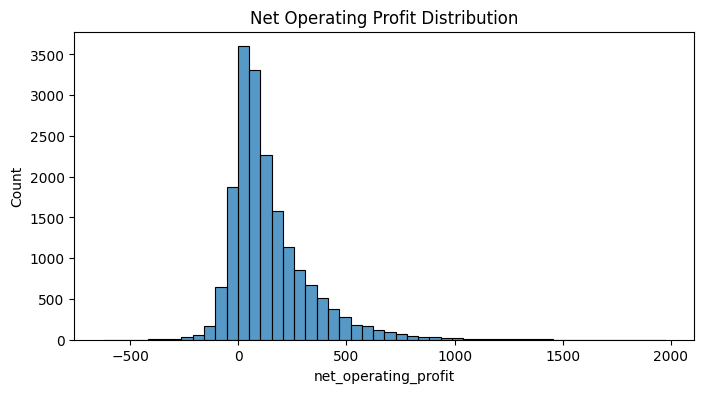

In [9]:
plt.figure(figsize=(8,4))
sns.histplot(df_model[TARGET], bins=50)
plt.title("Net Operating Profit Distribution")
plt.show()

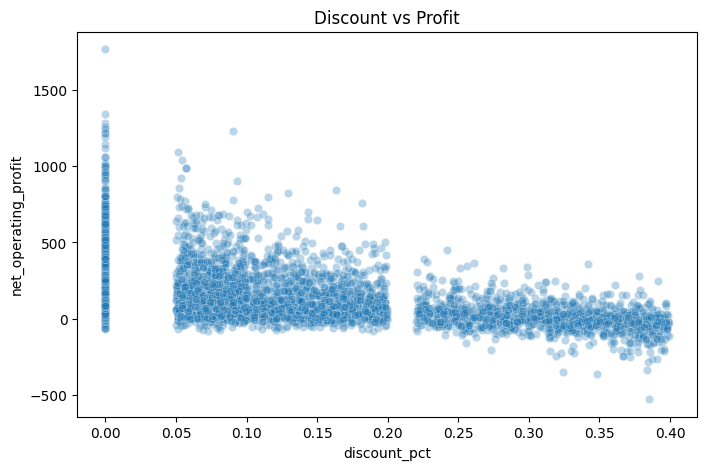

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_model.sample(5000),
    x="discount_pct",
    y=TARGET,
    alpha=0.3
)
plt.title("Discount vs Profit")
plt.show()

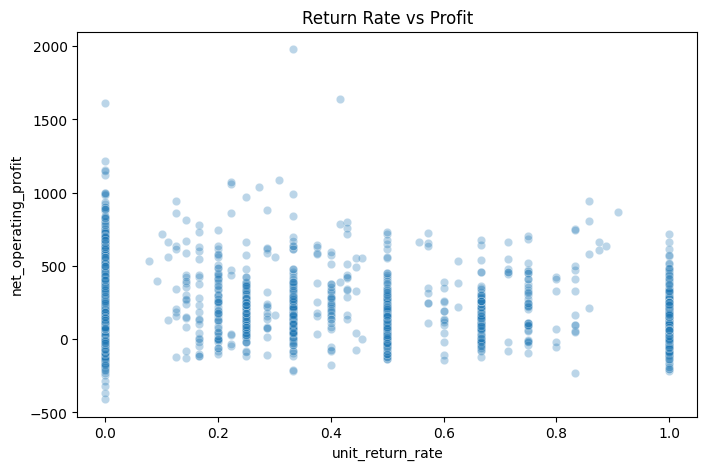

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_model.sample(5000),
    x="unit_return_rate",
    y=TARGET,
    alpha=0.3
)
plt.title("Return Rate vs Profit")
plt.show()

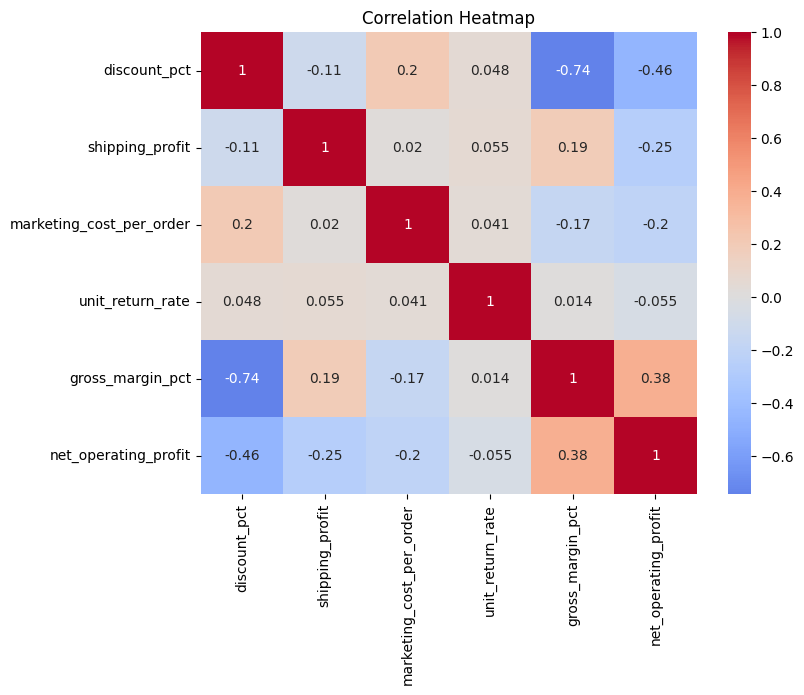

In [12]:
numeric_cols = [
    "discount_pct",
    "shipping_profit",
    "marketing_cost_per_order",
    "unit_return_rate",
    "gross_margin_pct",
    "net_operating_profit"
]

corr = df_model[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [13]:
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

categorical = [
    "segment",
    "acquisition_channel",
    "state_region",
    "discount_band"
]

numeric = [
    "discount_pct",
    "shipping_profit",
    "marketing_cost_per_order",
    "unit_return_rate",
    "gross_margin_pct"
]

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
    ]
)

In [14]:
lin_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lin_model.fit(X_train, y_train)

preds = lin_model.predict(X_test)

print("R2:", r2_score(y_test, preds))
print("MAE:", mean_absolute_error(y_test, preds))

R2: 0.3875311866053951
MAE: 104.68302486488899


In [15]:
ohe = lin_model.named_steps["preprocess"].named_transformers_["cat"]
cat_features = ohe.get_feature_names_out(categorical)

all_features = numeric + list(cat_features)

coefs = lin_model.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "feature": all_features,
    "coefficient": coefs
}).sort_values("coefficient", ascending=False)

coef_df.head(20)

,feature,coefficient
4,gross_margin_pct,212.012778
7,segment_Wholesale,42.535305
12,state_region_Metro,39.826665
15,state_region_Suburban,27.859073
10,acquisition_channel_Paid Social,14.450536
19,discount_band_No Discount,11.900826
17,discount_band_Low,8.365063
18,discount_band_Mid,7.515680
14,state_region_Rural,6.104477
2,marketing_cost_per_order,-1.186146


In [16]:
rf_model = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("R2:", r2_score(y_test, rf_preds))

R2: 0.47839148122643893


In [17]:
importances = rf_model.named_steps["model"].feature_importances_

rf_importance = pd.DataFrame({
    "feature": all_features,
    "importance": importances
}).sort_values("importance", ascending=False)

rf_importance.head(20)

,feature,importance
1,shipping_profit,0.274484
0,discount_pct,0.257294
4,gross_margin_pct,0.187229
2,marketing_cost_per_order,0.098369
3,unit_return_rate,0.056564
13,state_region_Remote,0.021449
7,segment_Wholesale,0.020644
12,state_region_Metro,0.011976
14,state_region_Rural,0.010152
8,acquisition_channel_Email,0.009084


In [18]:
driver_summary = coef_df.merge(
    rf_importance,
    on="feature",
    how="inner"
)

driver_summary["abs_coef"] = driver_summary["coefficient"].abs()

driver_summary.sort_values("importance", ascending=False).head(15)

,feature,coefficient,importance,abs_coef
10,shipping_profit,-3.470279,0.274484,3.470279
19,discount_pct,-419.747531,0.257294,419.747531
0,gross_margin_pct,212.012778,0.187229,212.012778
9,marketing_cost_per_order,-1.186146,0.098369,1.186146
14,unit_return_rate,-8.116826,0.056564,8.116826
18,state_region_Remote,-73.790216,0.021449,73.790216
1,segment_Wholesale,42.535305,0.020644,42.535305
2,state_region_Metro,39.826665,0.011976,39.826665
8,state_region_Rural,6.104477,0.010152,6.104477
12,acquisition_channel_Email,-4.775078,0.009084,4.775078


In [19]:
top_drivers = driver_summary.sort_values("importance", ascending=False).head(10)

top_drivers

,feature,coefficient,importance,abs_coef
10,shipping_profit,-3.470279,0.274484,3.470279
19,discount_pct,-419.747531,0.257294,419.747531
0,gross_margin_pct,212.012778,0.187229,212.012778
9,marketing_cost_per_order,-1.186146,0.098369,1.186146
14,unit_return_rate,-8.116826,0.056564,8.116826
18,state_region_Remote,-73.790216,0.021449,73.790216
1,segment_Wholesale,42.535305,0.020644,42.535305
2,state_region_Metro,39.826665,0.011976,39.826665
8,state_region_Rural,6.104477,0.010152,6.104477
12,acquisition_channel_Email,-4.775078,0.009084,4.775078


In [20]:
driver_summary.to_csv("driver_importance.csv", index=False)